In [1]:
!pip install clearml-agent

In [ ]:
# from clearml import Task
# import os

# # 1. 设置环境变量 (保持不变)
# %env CLEARML_WEB_HOST=https://app.clear.ml/
# %env CLEARML_API_HOST=https://api.clear.ml
# %env CLEARML_FILES_HOST=https://files.clear.ml
# %env CLEARML_API_ACCESS_KEY=R58U0GS1V7DPMV9POEA3L3E6WHH8EV
# %env CLEARML_API_SECRET_KEY=XQWoX03bgFcB4eJa6Ux8Kt7zmkaVmVdjg-3xBMa1kFdAdpywfbwfAKb8UzS-Rc2WWXU

# # 2. 初始化任务 (本地运行模式)
# task = Task.init(
#     project_name='InfinifyX', 
#     task_name='data_preprocessing_local_v1', # 改个名字区分本地运行
#     reuse_last_task_id=False
# )

# # 3. 上传当前的 Notebook
# task.upload_artifact('notebook', artifact_object='data_preprocessing.ipynb')


# # 4. 之后的所有代码都会在本地 SageMaker 运行，但日志会实时传到 ClearML
# print("This code is running LOCALLY on SageMaker, but tracking on ClearML!")



In [ ]:
# from clearml import Dataset
# #使用数据集案例
# # ==========================================
# # 选项 A: 获取小型数据集 (bdd100k_tiny)
# # 推荐在开发、调试阶段使用
# # ==========================================
# def get_tiny_dataset():
#     # 从 ClearML 获取数据集对象
#     dataset_tiny = Dataset.get(
#         dataset_project='InfinifyX', 
#         dataset_name='bdd100k_tiny'
#     )
#     # 获取本地副本路径。如果本地没有，会自动下载到 target_folder 指定的文件夹
#     tiny_path = dataset_tiny.get_mutable_local_copy(target_folder='bdd100k_tiny_data')
#     print(f"✅ 小型数据集已就绪，本地路径: {tiny_path}")
#     return tiny_path

# # ==========================================
# # 选项 B: 获取完整数据集 (bdd100k)
# # 用于正式跑实验和最终模型产出
# # ==========================================
# def get_full_dataset():
#     # 从 ClearML 获取完整数据集对象
#     dataset_full = Dataset.get(
#         dataset_project='InfinifyX', 
#         dataset_name='bdd100k'
#     )
#     full_path = dataset_full.get_mutable_local_copy(target_folder='bdd100k_full_data')
#     print(f"✅ 完整数据集已就绪，本地路径: {full_path}")
#     return full_path

# # --- 使用示例 ---
# # data_root = get_tiny_dataset()
# # data_root = get_full_dataset()

In [ ]:
# import os

# # 训练集图片路径
# train_images = os.path.join(data_root, 'train/images')
# # 训练集标签路径
# train_labels = os.path.join(data_root, 'train/labels')

# print(f"训练图片目录内容: {os.listdir(train_images)[:5]}") # 查看前5张图片

In [1]:
import os
from PIL import Image
from collections import Counter


In [2]:

def check_image_sizes(directory):
    """
    Iterates through images in a directory and checks if all images have the same dimensions.
    """
    if not os.path.exists(directory):
        print(f"Directory not found: {directory}")
        return

    sizes = []
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    
    print(f"Checking images in: {directory}...")
    
    # List all files in the directory
    files = [f for f in os.listdir(directory) if f.lower().endswith(image_extensions)]
    total_files = len(files)
    
    if total_files == 0:
        print("No images found in this directory.")
        return

    for filename in files:
        filepath = os.path.join(directory, filename)
        try:
            with Image.open(filepath) as img:
                # Get (width, height)
                sizes.append(img.size)
        except Exception as e:
            print(f"Could not read {filename}: {e}")

    # Count occurrences of each size
    size_counts = Counter(sizes)
    
    if len(size_counts) == 1:
        unique_size = list(size_counts.keys())[0]
        print(f"Success: All {total_files} images have the same size: {unique_size}")
    else:
        print(f"Warning: Multiple image sizes found in {directory}!")
        for size, count in size_counts.items():
            print(f"  - Size {size}: {count} images")

# Define the paths relative to your current directory

train_dir = 'bdd100k/train/images'
test_dir = 'bdd100k/test'

# Execute checks
print("--- Training Set ---")
check_image_sizes(train_dir)

print("\n--- Test Set ---")
check_image_sizes(test_dir)

--- Training Set ---
Checking images in: bdd100k/train/images...
Success: All 70000 images have the same size: (1280, 720)

--- Test Set ---
Checking images in: bdd100k/test...
Success: All 20000 images have the same size: (1280, 720)


In [ ]:
# import json
# import os

# # 配置路径
# input_json = 'InfinifyX/bdd100k/train/annotations/bdd100k_labels_images_train.json'
# output_json = 'InfinifyX/bdd100k/train/annotations/bdd100k_train_coco.json'

# def convert_bdd100k_to_coco(intput_file, output_file):
#     print("Reading BDD100K JSON...")
#     with open(intput_file, 'r') as f:
#         data = json.load(f)

#     # 定义 BDD100K 的 10 个标准类别
#     categories = [
#         {"id": 1, "name": "pedestrian"},
#         {"id": 2, "name": "rider"},
#         {"id": 3, "name": "car"},
#         {"id": 4, "name": "truck"},
#         {"id": 5, "name": "bus"},
#         {"id": 6, "name": "train"},
#         {"id": 7, "name": "motorcycle"},
#         {"id": 8, "name": "bicycle"},
#         {"id": 9, "name": "traffic light"},
#         {"id": 10, "name": "traffic sign"}
#     ]
#     cat_map = {cat["name"]: cat["id"] for cat in categories}

#     coco_format = {
#         "images": [],
#         "annotations": [],
#         "categories": categories
#     }

#     ann_id = 1
#     print("Converting labels...")
#     for img_idx, frame in enumerate(data):
#         # 1. 添加图片信息
#         # BDD100K 默认分辨率通常是 1280x720
#         image_info = {
#             "id": img_idx + 1,
#             "file_name": frame["name"],
#             "width": 1280,
#             "height": 720
#         }
#         coco_format["images"].append(image_info)

#         # 2. 添加标注信息
#         if "labels" in frame and frame["labels"] is not None:
#             for label in frame["labels"]:
#                 if "box2d" not in label:
#                     continue
                
#                 cat_name = label["category"]
#                 if cat_name not in cat_map:
#                     continue

#                 box2d = label["box2d"]
#                 x1 = box2d["x1"]
#                 y1 = box2d["y1"]
#                 x2 = box2d["x2"]
#                 y2 = box2d["y2"]
                
#                 width = x2 - x1
#                 height = y2 - y1

#                 ann = {
#                     "id": ann_id,
#                     "image_id": img_idx + 1,
#                     "category_id": cat_map[cat_name],
#                     "bbox": [x1, y1, width, height], # COCO 格式是 [x, y, w, h]
#                     "area": width * height,
#                     "iscrowd": 0,
#                     "segmentation": []
#                 }
#                 coco_format["annotations"].append(ann)
#                 ann_id += 1

#     print(f"Saving to {output_file}...")
#     with open(output_file, 'w') as f:
#         json.dump(coco_format, f)
#     print("Done!")



In [ ]:
# # 执行转换
# convert_bdd100k_to_coco(input_json, output_json)

In [3]:
import os
import json
import shutil
from tqdm import tqdm



# bdd_root = "bdd100k"   # path where you extracted dataset
train_images = "bdd100k/train/images"
val_images   = "bdd100k/val/images"
test_images  = "bdd100k/test"

 # Labels

train_labels = "bdd100k/train/annotations/bdd100k_labels_images_train.json"
val_labels   = "bdd100k/val/annotations/bdd100k_labels_images_val.json"

In [4]:
# Count images
print("Train Images:", len(os.listdir(train_images)))
print("Validation Images:", len(os.listdir(val_images)))
print("Test Images:", len(os.listdir(test_images)))

train_images_dir = "bdd100k/train/images"
train_labels_file = "bdd100k/train/annotations/bdd100k_labels_images_train.json"

# Count images
num_images = len(os.listdir(train_images_dir))

# Load annotations
with open(train_labels_file, "r") as f:
    annotations = json.load(f)

num_annotations = len(annotations)

print("Train Images:", num_images)
print("Train Annotations (entries in JSON):", num_annotations)

Train Images: 70000
Validation Images: 10000
Test Images: 20000
Train Images: 70000
Train Annotations (entries in JSON): 69863


In [5]:
%pip install opencv-python-headless

  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (60.4 MB)
Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [opencv-python-headless]v-python-headless]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluo

In [ ]:
# import os, json
# import cv2   # keep full cv2
# from PIL import Image

# # Paths
# bdd_root = r"bdd100k"
# images_dir = "bdd100k/train/images"
# labels_json = "bdd100k/train/annotations/bdd100k_labels_images_train.json"
# output_labels = "bdd100k/train/labels_yolo"

# os.makedirs(output_labels, exist_ok=True)

# # Load annotations
# with open(labels_json, "r") as f:
#     annotations = json.load(f)

# # Class mapping
# classes = ["person", "rider", "car", "truck", "bus", "train",
#            "motor", "bike", "traffic light", "traffic sign"]

# # Build quick lookup
# ann_dict = {ann["name"]: ann for ann in annotations}

# # Loop all images
# for img_name in os.listdir(images_dir):
#     label_path = os.path.join(output_labels, img_name.replace(".jpg", ".txt"))

#     if img_name not in ann_dict:
#         open(label_path, "w").close()
#         continue

#     img_ann = ann_dict[img_name]

#     # Get image size efficiently
#     img_path = os.path.join(images_dir, img_name)
#     with Image.open(img_path) as im:
#         W, H = im.size

#     with open(label_path, "w") as f_out:
#         for label in img_ann.get("labels", []):
#             if "box2d" not in label:
#                 continue
#             cls = label["category"]
#             if cls not in classes:
#                 continue
#             cls_id = classes.index(cls)

#             # Safe extraction
#             box = label["box2d"]
#             x1, y1, x2, y2 = box["x1"], box["y1"], box["x2"], box["y2"]

#             w = x2 - x1
#             h = y2 - y1
#             x_center = x1 + w / 2
#             y_center = y1 + h / 2

#             # Normalize
#             x_center /= W
#             y_center /= H
#             w /= W
#             h /= H

#             f_out.write(f"{cls_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")

# print("Conversion done! YOLO labels saved at:", output_labels)

In [6]:
import json
import pandas as pd

# Load labels
with open("bdd100k/train/annotations/bdd100k_labels_images_train.json") as f:
    data = json.load(f)

# Flatten into a DataFrame
records = []
for item in data:
    name = item["name"]
    for label in item["labels"]:
        category = label.get("category", None)
        attributes = label.get("attributes", {})
        box = label.get("box2d", None)

        records.append({
            "image": name,
            "category": category,
            "occluded": attributes.get("occluded"),
            "truncated": attributes.get("truncated"),
            "crowd": attributes.get("crowd"),
            "x1": box["x1"] if box else None,
            "y1": box["y1"] if box else None,
            "x2": box["x2"] if box else None,
            "y2": box["y2"] if box else None,
        })

df = pd.DataFrame(records)
df.head()

,image,category,occluded,truncated,crowd,x1,y1,x2,y2
0,0000f77c-6257be58.jpg,traffic light,False,False,None,1125.902264,133.184488,1156.978645,210.875445
1,0000f77c-6257be58.jpg,traffic light,False,False,None,1156.978645,136.637417,1191.507960,210.875443
2,0000f77c-6257be58.jpg,traffic sign,False,False,None,1101.731743,211.122087,1170.790370,233.566141
3,0000f77c-6257be58.jpg,traffic sign,False,True,None,0.000000,0.246631,100.381647,122.825696
4,0000f77c-6257be58.jpg,car,False,False,None,45.240919,254.530367,357.805838,487.906215


In [7]:
df.duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
1941232     True
1941233     True
1941234     True
1941235     True
1941236     True
Length: 1941237, dtype: bool

In [8]:
df.isnull().sum()

image              0
category           0
occluded      654366
truncated     654366
crowd        1941237
x1            654366
y1            654366
x2            654366
y2            654366
dtype: int64

In [9]:
df = df.dropna(subset = [col for col in df.columns if col != 'crowd'])
df = df.reset_index(drop=True)
df

,image,category,occluded,truncated,crowd,x1,y1,x2,y2
0,0000f77c-6257be58.jpg,traffic light,False,False,None,1125.902264,133.184488,1156.978645,210.875445
1,0000f77c-6257be58.jpg,traffic light,False,False,None,1156.978645,136.637417,1191.507960,210.875443
2,0000f77c-6257be58.jpg,traffic sign,False,False,None,1101.731743,211.122087,1170.790370,233.566141
3,0000f77c-6257be58.jpg,traffic sign,False,True,None,0.000000,0.246631,100.381647,122.825696
4,0000f77c-6257be58.jpg,car,False,False,None,45.240919,254.530367,357.805838,487.906215
...,...,...,...,...,...,...,...,...,...
1286866,fe189115-8dabb5b1.jpg,traffic sign,False,False,None,499.744761,290.551824,532.693937,305.528722
1286867,fe189115-8dabb5b1.jpg,traffic sign,False,False,None,507.233210,230.644231,528.200867,253.109578
1286868,fe189115-8dabb5b1.jpg,traffic sign,False,False,None,506.593579,261.346872,532.054306,288.305289
1286869,fe189115-8dabb5b1.jpg,car,False,False,None,710.279394,315.263706,737.237811,336.231364


In [10]:
print(df.describe(include="all"))

# Class distribution
print(df["category"].value_counts())

# Average bounding box width/height
df["width"] = df["x2"] - df["x1"]
df["height"] = df["y2"] - df["y1"]
print(df[["width", "height"]].describe())

                        image category occluded truncated crowd            x1  \
count                 1286871  1286871  1286871   1286871     0  1.286871e+06   
unique                  69863       10        2         2     0           NaN   
top     7a9d6ddb-f6db12be.jpg      car    False     False   NaN           NaN   
freq                       91   713211   678142   1197683   NaN           NaN   
mean                      NaN      NaN      NaN       NaN   NaN  5.620564e+02   
std                       NaN      NaN      NaN       NaN   NaN  2.870801e+02   
min                       NaN      NaN      NaN       NaN   NaN  0.000000e+00   
25%                       NaN      NaN      NaN       NaN   NaN  3.729372e+02   
50%                       NaN      NaN      NaN       NaN   NaN  5.652781e+02   
75%                       NaN      NaN      NaN       NaN   NaN  7.434699e+02   
max                       NaN      NaN      NaN       NaN   NaN  1.279178e+03   

                  y1       

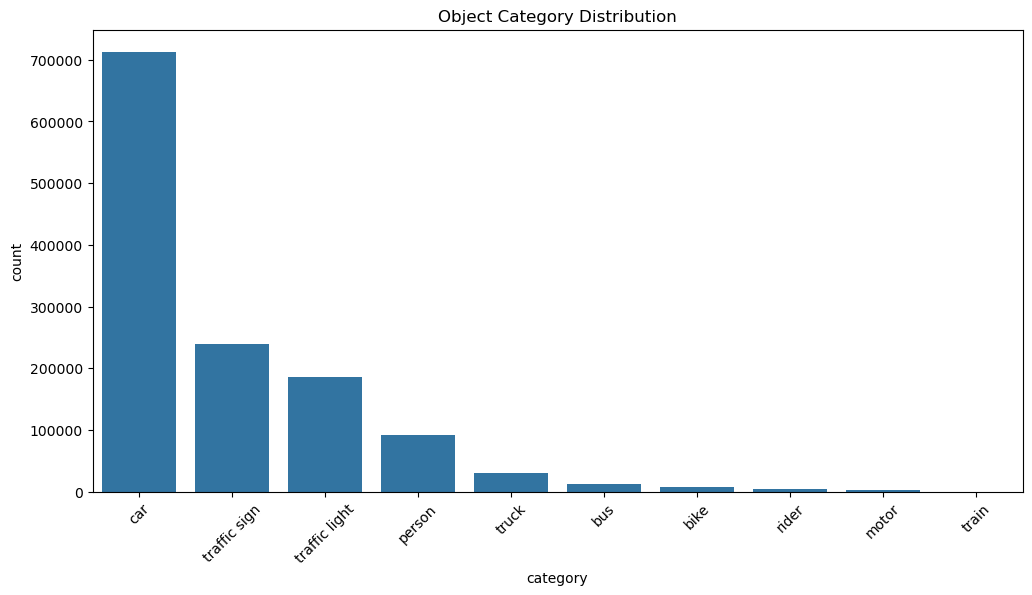

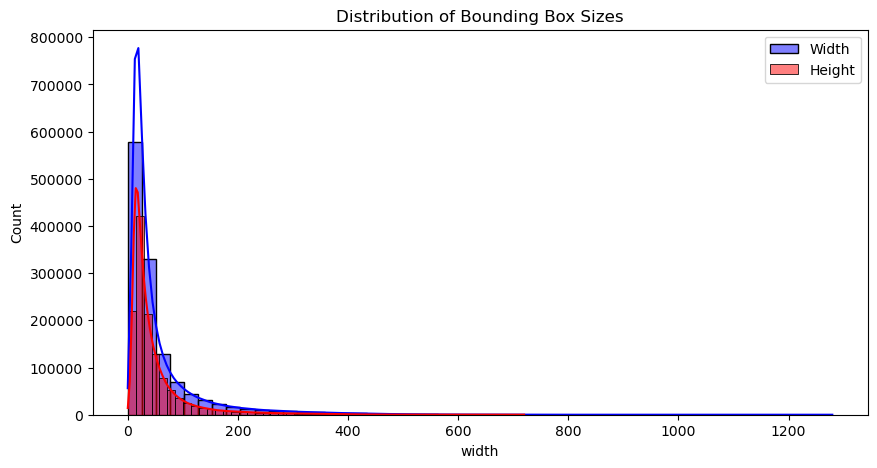

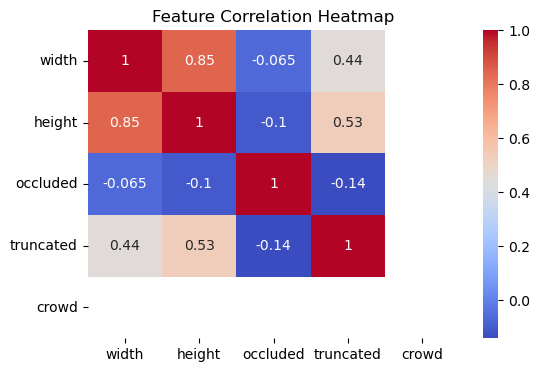

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Category distribution
plt.figure(figsize=(12,6))
sns.countplot(x="category", data=df, order=df["category"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Object Category Distribution")
plt.show()

# Bounding box sizes
plt.figure(figsize=(10,5))
sns.histplot(df["width"], bins=50, kde=True, color="blue", label="Width")
sns.histplot(df["height"], bins=50, kde=True, color="red", label="Height")
plt.legend()
plt.title("Distribution of Bounding Box Sizes")
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[["width","height","occluded","truncated","crowd"]].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
# New features
df["area"] = df["width"] * df["height"]
df["aspect_ratio"] = df["width"] / (df["height"] + 1e-6)  # avoid div by zero

# Encode categories
df_encoded = pd.get_dummies(df, columns=["category"])

# Scale numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ["width", "height", "area", "aspect_ratio"]
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

df_scaled.head()

,image,category,occluded,truncated,crowd,x1,y1,x2,y2,width,height,area,aspect_ratio
0,0000f77c-6257be58.jpg,traffic light,False,False,None,1125.902264,133.184488,1156.978645,210.875445,-0.337155,0.450255,-0.190904,-0.864061
1,0000f77c-6257be58.jpg,traffic light,False,False,None,1156.978645,136.637417,1191.507960,210.875443,-0.291536,0.394281,-0.184382,-0.795174
2,0000f77c-6257be58.jpg,traffic sign,False,False,None,1101.731743,211.122087,1170.790370,233.566141,0.164654,-0.445322,-0.228733,1.967869
3,0000f77c-6257be58.jpg,traffic sign,False,True,None,0.000000,0.246631,100.381647,122.825696,0.578483,1.177912,0.241928,-0.420891
4,0000f77c-6257be58.jpg,car,False,False,None,45.240919,254.530367,357.805838,487.906215,3.381779,2.973978,2.895747,0.129650


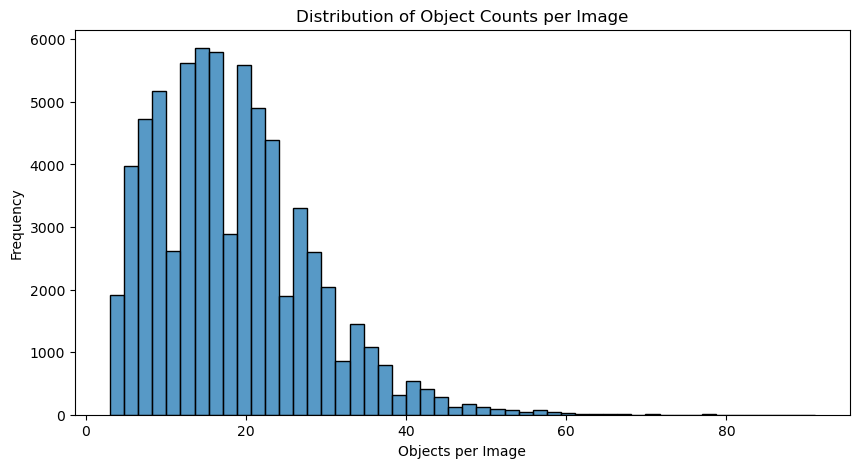

In [13]:
obj_count = df.groupby("image")["category"].count()

plt.figure(figsize=(10,5))
sns.histplot(obj_count, bins=50, kde=False)
plt.title("Distribution of Object Counts per Image")
plt.xlabel("Objects per Image")
plt.ylabel("Frequency")
plt.show()

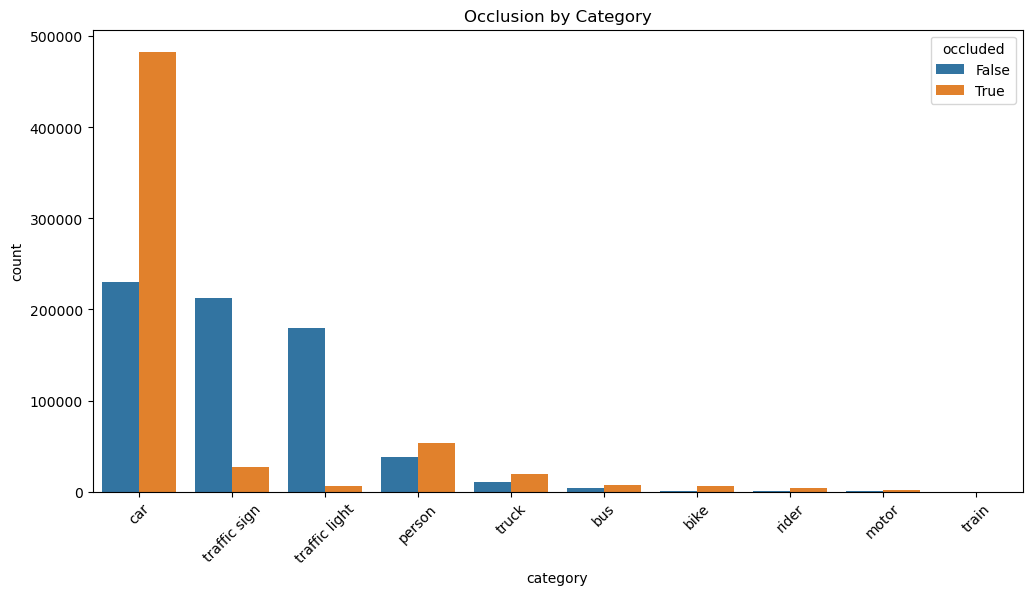

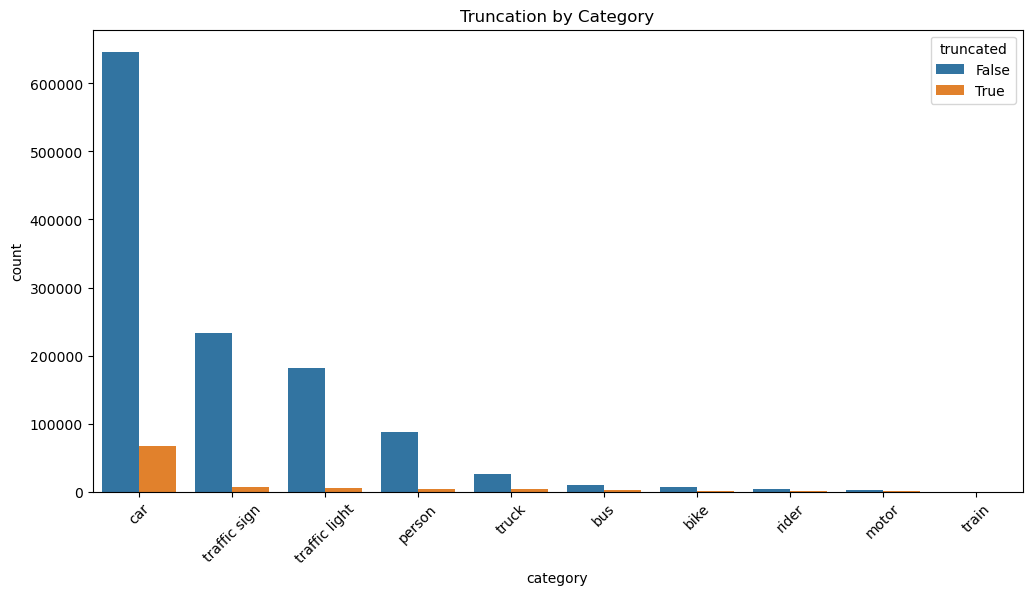

In [14]:
plt.figure(figsize=(12,6))
sns.countplot(x="category", hue="occluded", data=df, order=df["category"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Occlusion by Category")
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(x="category", hue="truncated", data=df, order=df["category"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Truncation by Category")
plt.show()

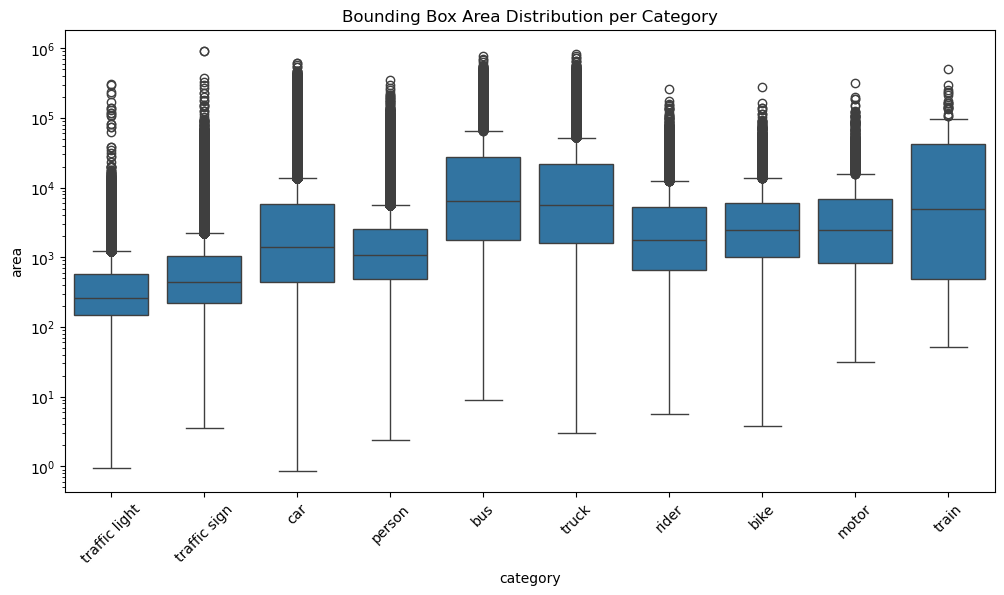

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(x="category", y="area", data=df)
plt.yscale("log")
plt.xticks(rotation=45)
plt.title("Bounding Box Area Distribution per Category")
plt.show()

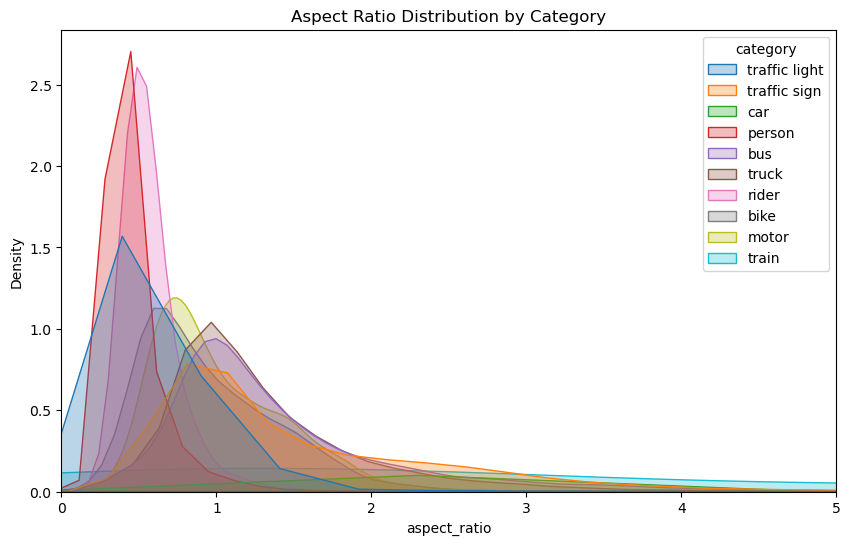

In [16]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x="aspect_ratio", hue="category", common_norm=False, fill=True, alpha=0.3)
plt.xlim(0, 5)
plt.title("Aspect Ratio Distribution by Category")
plt.show()

In [ ]:
# !pip install tqdm

In [ ]:
import os
import json
from tqdm import tqdm
from PIL import Image

# Paths
train_json = "bdd100k/train/annotations/bdd100k_labels_images_train.json"
val_json   = "bdd100k/val/annotations/bdd100k_labels_images_val.json"

train_img_dir = "bdd100k/train/images"
val_img_dir   = "bdd100k/val/images"

output_root = "bdd100k/"
os.makedirs(f"{output_root}/train/labels", exist_ok=True)
os.makedirs(f"{output_root}/val/labels", exist_ok=True)

# BDD100K categories → YOLO classes (10 classes)
categories = {
    "car": 0, "bus": 1, "truck": 2, "person": 3,
    "traffic light": 4, "traffic sign": 5, "bike": 6,
    "motor": 7, "train": 8, "other": 9
}

def convert_json_to_yolo(json_file, img_dir, split):
    with open(json_file, 'r') as f:
        data = json.load(f)

    for item in tqdm(data, desc=f"Converting {split}"):
        img_name = item["name"]
        img_path = os.path.join(img_dir, img_name)

        # Get image size
        if not os.path.exists(img_path):
            continue
        with Image.open(img_path) as im:
            w, h = im.size

        # Label file
        label_path = os.path.join(output_root, split, "labels", img_name.replace(".jpg", ".txt"))
        with open(label_path, "w") as out:
            for label in item["labels"]:
                if label["category"] not in categories:
                    continue
                cls = categories[label["category"]]
                box = label["box2d"]
                x1, y1, x2, y2 = box["x1"], box["y1"], box["x2"], box["y2"]

                # Convert to YOLO format
                x_center = (x1 + x2) / 2.0 / w
                y_center = (y1 + y2) / 2.0 / h
                bw = (x2 - x1) / w
                bh = (y2 - y1) / h

                out.write(f"{cls} {x_center:.6f} {y_center:.6f} {bw:.6f} {bh:.6f}\n")

# Run conversion
convert_json_to_yolo(train_json, train_img_dir, "train")
convert_json_to_yolo(val_json, val_img_dir, "val")

In [ ]:
# import shutil, os

# def reset_and_subset(src_images, src_labels, dst_images, dst_labels, n=200):
#     # Remove old folder if exists
#     if os.path.exists(dst_images):
#         shutil.rmtree(dst_images)
#     if os.path.exists(dst_labels):
#         shutil.rmtree(dst_labels)
    
#     os.makedirs(dst_images, exist_ok=True)
#     os.makedirs(dst_labels, exist_ok=True)
    
#     from glob import glob
#     for i, img_path in enumerate(glob(os.path.join(src_images, "*.jpg"))[:n]):
#         base = os.path.basename(img_path).replace(".jpg", "")
#         label_path = os.path.join(src_labels, base + ".txt")

#         shutil.copy(img_path, dst_images)
#         if os.path.exists(label_path):
#             shutil.copy(label_path, dst_labels)

# # Reset and subset again
# reset_and_subset("bdd100k/train/images",
#                  "bdd100k/train/labels",
#                  "bdd100k_tiny/train/images",
#                  "bdd100k_tiny/train/labels",
#                  n=2000)

# reset_and_subset("bdd100k/val/images",
#                  "bdd100k/val/labels",
#                  "bdd100k_tiny/val/images",
#                  "bdd100k_tiny/val/labels",
#                  n=400)

In [ ]:
# yaml_content = """
# train: bdd100k_tiny/train/images
# val: bdd100k_tiny/val/images

# nc: 10
# names: ['car','bus','truck','person','traffic light','traffic sign','bike','motor','train','other']
# """

# with open("bdd100k_tiny.yaml", "w") as f:
#     f.write(yaml_content)

# print("✅ bdd100k_tiny.yaml created!")

In [ ]:
# #test for tiny set, need to install ultralytics firstly-

# from ultralytics import YOLO

# model = YOLO("yolov8s.pt")

# results = model.train(
#     data="bdd100k_tiny.yaml",
#     epochs=15,      
#     imgsz=512,     
#     batch=16
# )

# print("Best model saved at:", results.save_dir)